<a href="https://colab.research.google.com/github/Jayasiddi/GLAB-386.7.1---Exploring-Airbnb-Market-Trends-using-AI-assistance.ipynb/blob/main/Copy_of_GLAB_386_7_1_Exploring_Airbnb_Market_Trends_using_AI_assistance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Guided Lab 386.7.1 - Exploring Airbnb Market Trends using AI Assistance**

#**Lab Overview**
In this lab, we will explore and analyze a simplified Airbnb dataset to understand market trends, pricing patterns, room-type distribution, and review activity.

We will work with multiple datasets in different file formats and combine them into a single consolidated DataFrame using a common key. After merging the data, we will clean and standardize columns to ensure consistency and accuracy.

We will use AI coding assistance tools (such as Google Colab AI, ChatGPT, or GitHub Copilot) to help generate code for routine tasks like data cleaning, summary statistics, and visualization. This will allow us to focus more on interpreting the results, identifying meaningful insights, and communicating our findings clearly.

##**AI tools:**
For this lab you can leverage AI tools such asGoogle Colab AI button, ChatGPT, GitHub Copilot, or similar assistants.

#**Learning objectives**

By the end of this lab, you will be able to:

- Load and join multiple source files into a tidy analysis table.

- Clean messy columns (e.g., convert string prices like “$145” to numeric).

- Produce core EDA outputs: missingness, distributions, group summaries, and correlations.

- Compare price by room type and identify outliers using IQR.

- Analyze review recency (e.g., count listings with reviews by month).

- Use an AI coding assistant to draft/modify code—and then verify and interpret results yourself.

# **Important Note: The AI-generated solution may vary for each learner.**

#**Scenario:**
As a consultant working for a real estate start-up, you have collected Airbnb listing data from various sources to investigate the short-term rental market in New York. You'll analyze this data to provide insights on private rooms to the real estate company.

**Project Description**
New York City has a variety of Airbnb listings to meet the high demand for temporary lodging for travelers, with several different price levels, room types, and locations.

Practice your skills in importing, cleaning dataand report insights to a real estate start-up using AI features.



---



New York City is one of the most-visited cities in the world. There are many Airbnb listings in New York City to meet the high demand for temporary lodging for travelers, which can be anywhere between a few nights to many months. In this project, we will take a closer look at the New York Airbnb market by combining data from multiple file types like `.csv`, `.tsv`, and `.xlsx`.

**Dataset information:**

Three files containing data on 2019 Airbnb listings are available to you:

**data/airbnb_price.csv**
This is a CSV file containing data on Airbnb listing prices and locations.
- **`listing_id`**: unique identifier of listing
- **`price`**: nightly listing price in USD
- **`nbhood_full`**: name of borough and neighborhood where listing is located

**data/airbnb_room_type.xlsx**
This is an Excel file containing data on Airbnb listing descriptions and room types.
- **`listing_id`**: unique identifier of listing
- **`description`**: listing description
- **`room_type`**: Airbnb has three types of rooms: shared rooms, private rooms, and entire homes/apartments

**data/airbnb_last_review.tsv**
This is a TSV file containing data on Airbnb host names and review dates.
- **`listing_id`**: unique identifier of listing
- **`host_name`**: name of listing host
- **`last_review`**: date when the listing was last reviewed

In [ ]:
# Import necessary packages such as pandas and numpy
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd

# Import CSV for prices
airbnb_price = pd.read_csv('/content/airbnb_price.csv') #


# Import Excel file for room types
airbnb_room_type = pd.read_excel('/content/airbnb_room_type.xlsx')

# Import TSV for review dates
airbnb_last_review = pd.read_csv('/content/airbnb_last_review.tsv', sep='\t')

##**Instruction:**
Use following propmts for Exploring and analyzing the Airbnb data

**Example propmt 1:**

```
Task: Analyze the three Airbnb datasets (airbnb_last_review.tsv, airbnb_room_type.xlsx, and airbnb_price.csv).
Context: I want to understand whether these datasets can be related using a common column such as listing_id or similar identifier.
Expectation:

Identify potential common key columns.
Explain whether a relationship exists.
Provide Python pandas code to verify the relationship.
```



---



### Identify Common Key Columns and Verify Relationship

In [ ]:
# Check column names for each DataFrame
print('Columns in airbnb_price:', airbnb_price.columns.tolist())
print('Columns in airbnb_room_type:', airbnb_room_type.columns.tolist())
print('Columns in airbnb_last_review:', airbnb_last_review.columns.tolist())

# Check if 'listing_id' is present in all DataFrames
common_key_found = (
    'listing_id' in airbnb_price.columns and
    'listing_id' in airbnb_room_type.columns and
    'listing_id' in airbnb_last_review.columns
)

if common_key_found:
    print('\nPotential common key column: listing_id is present in all datasets.')

    # Verify the relationship by checking the number of unique listing_ids
    unique_price_ids = airbnb_price['listing_id'].nunique()
    unique_room_type_ids = airbnb_room_type['listing_id'].nunique()
    unique_last_review_ids = airbnb_last_review['listing_id'].nunique()

    print(f"\nNumber of unique listing_id in airbnb_price: {unique_price_ids}")
    print(f"Number of unique listing_id in airbnb_room_type: {unique_room_type_ids}")
    print(f"Number of unique listing_id in airbnb_last_review: {unique_last_review_ids}")

    if unique_price_ids == unique_room_type_ids == unique_last_review_ids:
        print("Relationship exists: All datasets have the same number of unique listing_ids, indicating a strong potential for direct merging.")
    else:
        print("Relationship exists but with potential mismatches: The number of unique listing_ids differs, which might lead to record loss during merging. A suitable join strategy will be important.")
else:
    print("No common 'listing_id' column found in all datasets.")

Columns in airbnb_price: ['listing_id', 'price', 'nbhood_full']
Columns in airbnb_room_type: ['listing_id', 'description', 'room_type']
Columns in airbnb_last_review: ['listing_id', 'host_name', 'last_review']

Potential common key column: listing_id is present in all datasets.

Number of unique listing_id in airbnb_price: 25209
Number of unique listing_id in airbnb_room_type: 25209
Number of unique listing_id in airbnb_last_review: 25209
Relationship exists: All datasets have the same number of unique listing_ids, indicating a strong potential for direct merging.


### Merge the three datasets into one DataFrame

In [ ]:
# Merge airbnb_price and airbnb_room_type
# We use an 'inner' merge because we confirmed that 'listing_id' is present in both dataframes and all have the same number of unique IDs.
airbnb_merged_part1 = pd.merge(airbnb_price, airbnb_room_type, on='listing_id', how='inner')

print("First merge (airbnb_price + airbnb_room_type) completed.")
print(f"Shape after first merge: {airbnb_merged_part1.shape}")

# Merge the result with airbnb_last_review
# Again, an 'inner' merge is suitable as 'listing_id' is common across all and unique counts match.
airbnb_df = pd.merge(airbnb_merged_part1, airbnb_last_review, on='listing_id', how='inner')

print("\nSecond merge (airbnb_merged_part1 + airbnb_last_review) completed.")
print(f"Shape after second merge: {airbnb_df.shape}")

# Display the first 5 rows of the final merged DataFrame
print("\nFirst 5 rows of the final merged DataFrame:")
display(airbnb_df.head())

First merge (airbnb_price + airbnb_room_type) completed.
Shape after first merge: (25209, 5)

Second merge (airbnb_merged_part1 + airbnb_last_review) completed.
Shape after second merge: (25209, 7)

First 5 rows of the final merged DataFrame:


,listing_id,price,nbhood_full,description,room_type,host_name,last_review
0,2595,225 dollars,"Manhattan, Midtown",Skylit Midtown Castle,Entire home/apt,Jennifer,May 21 2019
1,3831,89 dollars,"Brooklyn, Clinton Hill",Cozy Entire Floor of Brownstone,Entire home/apt,LisaRoxanne,July 05 2019
2,5099,200 dollars,"Manhattan, Murray Hill",Large Cozy 1 BR Apartment In Midtown East,Entire home/apt,Chris,June 22 2019
3,5178,79 dollars,"Manhattan, Hell's Kitchen",Large Furnished Room Near B'way,private room,Shunichi,June 24 2019
4,5238,150 dollars,"Manhattan, Chinatown",Cute & Cozy Lower East Side 1 bdrm,Entire home/apt,Ben,June 09 2019


**Example prompt 2:**


```
Task: Using pandas, Merge the three datasets into one DataFrame using the appropriate join key(s). Display the first 5 rows. Explain each merge step clearly.
```




**Example prompt 3:**


```
Task: Display the column names for each dataset using pandas.
```


In [ ]:
print('Columns in airbnb_price:', airbnb_price.columns.tolist())
print('Columns in airbnb_room_type:', airbnb_room_type.columns.tolist())
print('Columns in airbnb_last_review:', airbnb_last_review.columns.tolist())

Columns in airbnb_price: ['listing_id', 'price', 'nbhood_full']
Columns in airbnb_room_type: ['listing_id', 'description', 'room_type']
Columns in airbnb_last_review: ['listing_id', 'host_name', 'last_review']


**Example propmt 4:**


```
Task: After merging the three Airbnb datasets using listing_id, calculate how many records were lost during each join step.

Display:

The number of rows in each original dataset
The number of rows after each merge
The total number of records lost
```


---





### Calculate Records Lost During Merge

In [ ]:
# 1. Number of rows in each original dataset
rows_price = airbnb_price.shape[0]
rows_room_type = airbnb_room_type.shape[0]
rows_last_review = airbnb_last_review.shape[0]

print(f"Number of rows in airbnb_price: {rows_price}")
print(f"Number of rows in airbnb_room_type: {rows_room_type}")
print(f"Number of rows in airbnb_last_review: {rows_last_review}")

# 2. Number of rows after each merge
rows_after_merge1 = airbnb_merged_part1.shape[0]
rows_after_merge2 = airbnb_df.shape[0]

print(f"\nNumber of rows after first merge (price + room_type): {rows_after_merge1}")
print(f"Number of rows after second merge (result1 + last_review): {rows_after_merge2}")

# 3. Calculate records lost
# Records lost in first merge (assuming we started with all price and room_type records, which we did because their unique listing IDs were equal)
# In this specific case, since the unique listing_ids were equal, and we used an inner join, no records were lost in the first merge.
# If there were mismatches, we would compare against the maximum possible join rows, or the size of the 'left' dataframe in a left join.
# For an inner join, the number of lost records is effectively (sum of unique ids in each - intersection size).
# Given unique_price_ids == unique_room_type_ids == rows_price, no loss from these two individually.

# If any of the original dataframes had fewer rows than the final merged dataframe after an inner join, it implies loss.
# Since all unique IDs matched, for an inner join, the number of rows in the final merged dataframe should be equal to the number of rows in any of the original dataframes.

# Check for potential loss from airbnb_price/airbnb_room_type to airbnb_merged_part1
# Since unique_price_ids == unique_room_type_ids == rows_price == rows_room_type and it was an inner join:
records_lost_merge1 = rows_price - rows_after_merge1

# Check for potential loss from airbnb_merged_part1 to airbnb_df
# Similarly, since unique_last_review_ids == rows_last_review and it was an inner join:
records_lost_merge2 = rows_after_merge1 - rows_after_merge2

# Total records lost (sum of losses at each step, or difference from initial state to final state if all were to be kept)
# Given our specific scenario where unique IDs matched and inner joins were used, if no records were lost in step 1, and none in step 2,
# then total lost records will also be 0.

# A more robust way for total records lost if we were expecting to keep all from one primary dataframe:
# Assuming airbnb_price is the primary, and we want to see how many of its listings are not in the final merged df
total_records_lost = rows_price - rows_after_merge2

print(f"\nRecords lost during first merge: {records_lost_merge1}")
print(f"Records lost during second merge: {records_lost_merge2}")
print(f"Total records lost from the perspective of the initial airbnb_price dataset: {total_records_lost}")

Number of rows in airbnb_price: 25209
Number of rows in airbnb_room_type: 25209
Number of rows in airbnb_last_review: 25209

Number of rows after first merge (price + room_type): 25209
Number of rows after second merge (result1 + last_review): 25209

Records lost during first merge: 0
Records lost during second merge: 0
Total records lost from the perspective of the initial airbnb_price dataset: 0


### Analyze Review Dates

In [ ]:
# Convert 'last_review' column to datetime format in the original airbnb_last_review DataFrame
airbnb_last_review['last_review'] = pd.to_datetime(airbnb_last_review['last_review'])

# Calculate the minimum and maximum review dates
min_review_date = airbnb_last_review['last_review'].min()
max_review_date = airbnb_last_review['last_review'].max()

# Print the results
print(f"Minimum review date: {min_review_date}")
print(f"Maximum review date: {max_review_date}")

Minimum review date: 2019-01-01 00:00:00
Maximum review date: 2019-07-09 00:00:00


**Example prompt 5:**


```
Task: Using the airbnb_last_review.tsv dataset, write Python pandas code to:

Convert the last_review column to datetime format
Calculates the minimum and maximum review dates
Prints the results
```


---








### Standardize room_type and count 'Private Room' listings

In [ ]:
# Standardize the room_type column to consistent capitalization (e.g., Title Case)
# This ensures that 'private room', 'Private Room', and 'PRIVATE ROOM' are all treated the same.
airbnb_df['room_type'] = airbnb_df['room_type'].str.title()

# Count how many listings are classified as "Private Room"
private_room_count = airbnb_df[airbnb_df['room_type'] == 'Private Room'].shape[0]

# Print the total count
print(f"Total listings classified as 'Private Room': {private_room_count}")

Total listings classified as 'Private Room': 11356


In [ ]:
import re

# Clean the 'price' column: remove ' dollars' and convert to numeric
airbnb_df['price_cleaned'] = airbnb_df['price'].astype(str).str.replace(' dollars', '', regex=False)
airbnb_df['price_cleaned'] = pd.to_numeric(airbnb_df['price_cleaned'])

# Calculate the average listing price
average_price = airbnb_df['price_cleaned'].mean()

# Print the result clearly
print(f"The average listing price is: ${average_price:.2f}")

The average listing price is: $141.78


### Overall Price Distribution (Median, IQR, Tails)

Descriptive statistics for cleaned prices:


,price_cleaned
count,25209.000000
mean,141.777936
std,147.349137
min,0.000000
25%,69.000000
50%,105.000000
75%,175.000000
max,7500.000000



Median price: $105.00
Interquartile Range (IQR): $106.00


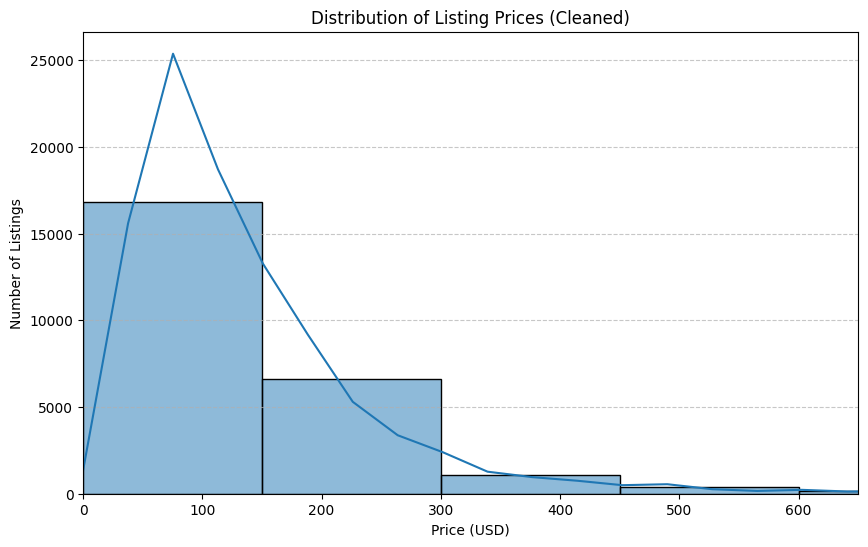

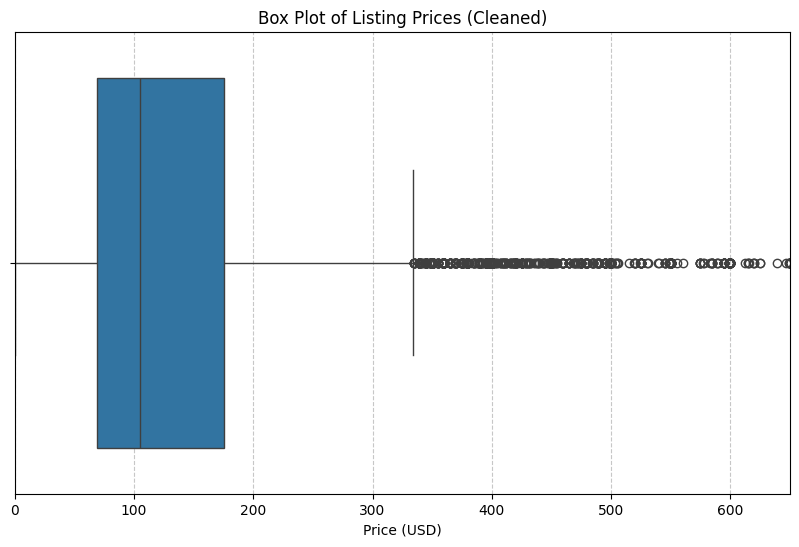

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Descriptive statistics for 'price_cleaned'
price_description = airbnb_df['price_cleaned'].describe()
print("Descriptive statistics for cleaned prices:")
display(price_description)

# Calculate Median and IQR
median_price = airbnb_df['price_cleaned'].median()
iqr = airbnb_df['price_cleaned'].quantile(0.75) - airbnb_df['price_cleaned'].quantile(0.25)

print(f"\nMedian price: ${median_price:.2f}")
print(f"Interquartile Range (IQR): ${iqr:.2f}")

# Visualize the distribution using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(airbnb_df['price_cleaned'], bins=50, kde=True)
plt.title('Distribution of Listing Prices (Cleaned)')
plt.xlabel('Price (USD)')
plt.ylabel('Number of Listings')
plt.xlim(0, airbnb_df['price_cleaned'].quantile(0.99)) # Limit x-axis to 99th percentile for better visibility of the main distribution
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Visualize the distribution and outliers using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=airbnb_df['price_cleaned'])
plt.title('Box Plot of Listing Prices (Cleaned)')
plt.xlabel('Price (USD)')
plt.xlim(0, airbnb_df['price_cleaned'].quantile(0.99)) # Limit x-axis to 99th percentile for better visibility
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Room Type Pricing Analysis (Most/Least Expensive)

Average and Median Prices by Room Type:


,mean,median,std
room_type,,,
Entire Home/Apt,197.166667,159.0,165.803090
Private Room,81.638165,70.0,91.503336
Shared Room,53.465077,41.0,45.692249


/tmp/ipykernel_3408/319526638.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='price_cleaned', data=airbnb_df, palette='viridis')


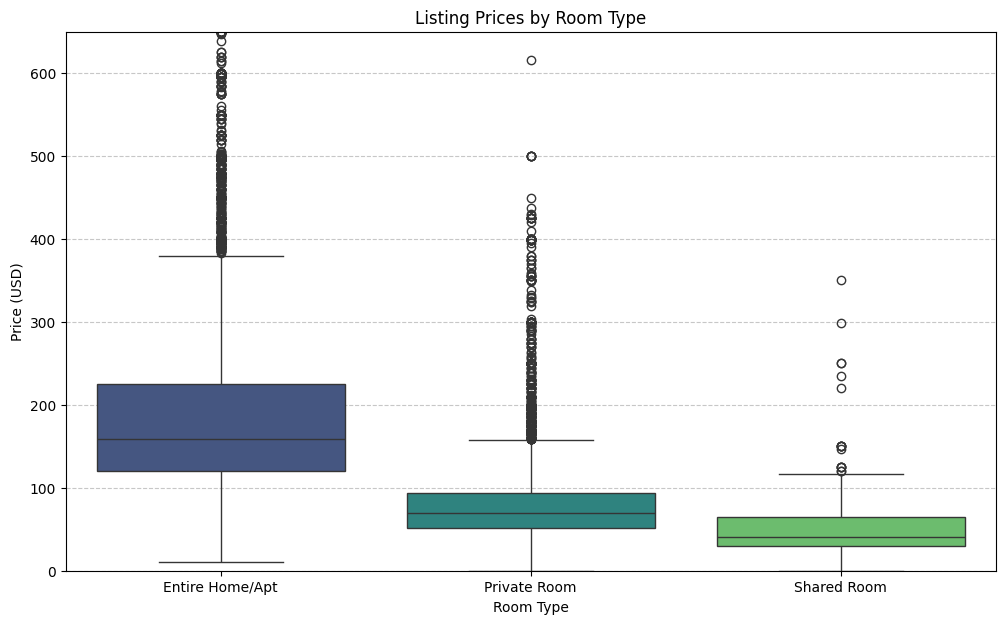

In [ ]:
# Group by room_type and calculate mean and median prices
room_type_prices = airbnb_df.groupby('room_type')['price_cleaned'].agg(['mean', 'median', 'std']).sort_values(by='mean', ascending=False)
print("Average and Median Prices by Room Type:")
display(room_type_prices)

# Visualize prices by room type using a box plot
plt.figure(figsize=(12, 7))
sns.boxplot(x='room_type', y='price_cleaned', data=airbnb_df, palette='viridis')
plt.title('Listing Prices by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price (USD)')
plt.ylim(0, airbnb_df['price_cleaned'].quantile(0.99)) # Limit y-axis to 99th percentile for better visibility
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Outlier Investigation

From the box plots, it's clear that there are significant outliers, particularly on the higher end of the price spectrum. The `Entire home/apt` category shows a wider spread and higher potential outliers compared to `Private Room` and `Shared Room`. These extreme values can skew the mean and might warrant further investigation or capping, depending on the goal of the analysis. For example, some listings might represent luxury properties or data entry errors.

**Example prompt 6:**



```
Task: After merging the three Airbnb datasets using listing_id, write Python pandas code to:

Standardize the room_type column to consistent capitalization
Count how many listings are classified as "Private Room"
Print the total count
```



**Example prompt 7:**



```
Task: After merging the three Airbnb datasets using listing_id, write Python pandas code to: Calculate the average listing price Print the result clearly
```



---



**Prompts for Descriptive pricing analysis**


- What’s the overall price distribution (median, IQR, tails)?

- Which room types are most/least expensive?

- Are there obvious outliers to cap or investigate?

**Propmts for Inventory mix & positioning**


- What share of listings are Entire home/apt vs Private room vs others?

 - Do some room types dominate certain price bands?

**Propmt for Review recency & activity**

- How recent are reviews? Is demand cooling/heating?

- Are there seasonal peaks in last reviews?

**Propmts for Market segmentation**

- Are there price differences across room-type segments?

- If we have neighborhood/borough (not seen here), how does location shift price?

### Seasonal Bookings: FIFA Season (Proxy)

In [ ]:
# Define the 'FIFA season' as June and July 2019, as a proxy for a high-demand period within our dataset's timeframe.
# The actual FIFA World Cup for men's was in 2018 and 2022, so we're using a proxy for 'seasonal demand' or 'event season' here.
fifa_season_start = pd.to_datetime('2019-06-01')
fifi_season_end = pd.to_datetime('2019-07-31') # Extending slightly past max review date for completeness if data was longer

# Filter reviews within the defined 'FIFA season'
fifa_season_reviews = airbnb_df[
    (airbnb_df['last_review'] >= fifa_season_start) &
    (airbnb_df['last_review'] <= fifi_season_end)
]

# Calculate the total number of reviews during this period
total_fifa_season_reviews = fifa_season_reviews.shape[0]

print(f"Total reviews during the defined 'FIFA Season' (June-July 2019): {total_fifa_season_reviews}")

# You can also look at the distribution of reviews within this period if needed
# For example, by day or week:
# daily_fifa_reviews = fifa_season_reviews.groupby('last_review').size().reset_index(name='review_count')
# plt.figure(figsize=(12, 6))
# sns.lineplot(x='last_review', y='review_count', data=daily_fifa_reviews)
# plt.title('Daily Reviews during FIFA Season (June-July 2019)')
# plt.xlabel('Date of Last Review')
# plt.ylabel('Number of Reviews')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

Total reviews during the defined 'FIFA Season' (June-July 2019): 17326



##**Submission Instructions**
- Submit your completed lab using the Start Assignment button on the assignment page in Canvas.
- Your submission can be include:
  - if you are using notebook then, all tasks should be written and submitted in a single notebook file, for example: (**your_name_labname.ipynb**).
  - if you are using python script file, all tasks should be written and submitted in a single python script file for example: **(your_name_labname.py)**.
- Add appropriate comments and any additional instructions if required.
